# ResNet

## 残差连接
在函数中加入一个快速通道，使输入可以直接传递到输出。
$$ f(x) = x + g(x)$$

### 梯度
此时计算梯度
$$ \frac{\partial loss}{\partial x} = \frac{\partial loss}{\partial f(x)} \cdot \frac{\partial f(x)}{\partial x} = \frac{\partial loss}{\partial f(x)} \cdot (1 + \frac{\partial g(x)}{\partial x})$$
- 梯度中有一个恒等项1，使得梯度不会消失。

$$\frac{\partial loss}{\partial x} = \frac{\partial loss}{\partial f(x)}  + \frac{\partial loss}{\partial f(x)} \cdot \frac{\partial g(x)}{\partial x}$$
- 每一层的梯度都包含了上一层的梯度，使得梯度可以直接传递到最前面。

### 残差层
将卷积层、线性层等作为函数 $g(x)$，加入残差连接，形成残差层 $f(x)$。

此时 $g(x)$ 的目标是学习一个残差函数，即目标映射与输入的差值。

因此模型有了“摆烂”的能力，即一层如果学不好，可以直接原样输出，保证梯度传递。

![residual](./images/residual.svg)


## ResNet 残差块
VGG 块的基础上加入 batch norm 和残差连接，形成 ResNet 残差块。

也可以在残差连接处额外加一个 1x1 卷积层，调整通道数。

![res_block](./images/res_block.svg)


## ResNet 网络结构
类似 VGG 和 GoogLeNet 的总体架构，但换成了残差块。
- 高宽减半 ResNet 块（步幅2）
- 后接多个高宽不变 ResNet 块

![resnet](./images/resnet.svg)


## 实现


In [1]:
import torch
from torch import nn
import torchinfo
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


### 残差块


In [3]:
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1conv=False, strides=1):
        """
        @param input_channels: 输入通道数
        @param num_channels: 输出通道数
        @param use_1x1conv: 是否使用 1x1 卷积（调整通道）
        @param strides: 第一个卷积层步幅
        """
        assert (input_channels == num_channels) or use_1x1conv, "输入输出通道数不一致，必须使用 1x1 卷积调整通道数"
        super().__init__()
        # 第一个卷积层（可调步幅），在这里把通道变成输出通道数
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1, stride=strides)
        # 第二个卷积层不改变高宽和通道
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1)
        if use_1x1conv:
            # 如果需要调整通道数（输入输出通道不一样），则使用 1x1 卷积层
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)
        self.relu = nn.ReLU(inplace=True) # inplace=True 表示直接在原来的内存上进行操作，节省内存

    def forward(self, X):
        # 得到 g(x)
        Y = self.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        # 是否调整通道数
        if self.conv3:
            X = self.conv3(X)
        # 残差连接
        Y += X
        return self.relu(Y)

输入输出形状不变


增加通道，减半高宽（常见操作）


In [5]:
blk = Residual(3, 6, use_1x1conv=True, strides=2)
X = torch.rand(4, 3, 6, 6)
blk(X).shape # 4, 6, 3, 3

torch.Size([4, 6, 3, 3])

### ResNet 网络


In [10]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

def resnet_block(input_channels, num_channels, num_residuals, first_block=False)->nn.Sequential:
    """
    @param input_channels: 输入通道数
    @param num_channels: 输出通道数
    @param num_residuals: 残差块的数量
    @param first_block: 是否是第一个残差块（第一个残差块不需要调整通道数和高宽）
    """
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            # 第一个残差块需要调整通道数和高宽
            blk.append(Residual(input_channels, num_channels, use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return nn.Sequential(*blk)

b2 = resnet_block(64, 64, 2, first_block=True)
b3 = resnet_block(64, 128, 2)
b4 = resnet_block(128, 256, 2)
b5 = resnet_block(256, 512, 2)

net = nn.Sequential(
    b1, b2, b3, b4, b5,
    nn.AdaptiveAvgPool2d((1, 1)), # 全局平均池化
    nn.Flatten(),
    nn.Linear(512, 10) # 输出 10 类
)

In [11]:
torchinfo.summary(net,
                  input_size=(1, 1, 224, 224),
                  col_names=["input_size", "output_size", "num_params", "mult_adds"],
                  col_width=20,
                  depth=2)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Mult-Adds
Sequential                               [1, 1, 224, 224]     [1, 10]              --                   --
├─Sequential: 1-1                        [1, 1, 224, 224]     [1, 64, 56, 56]      --                   --
│    └─Conv2d: 2-1                       [1, 1, 224, 224]     [1, 64, 112, 112]    3,200                40,140,800
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]    [1, 64, 112, 112]    128                  128
│    └─ReLU: 2-3                         [1, 64, 112, 112]    [1, 64, 112, 112]    --                   --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]    [1, 64, 56, 56]      --                   --
├─Sequential: 1-2                        [1, 64, 56, 56]      [1, 64, 56, 56]      --                   --
│    └─Residual: 2-5                     [1, 64, 56, 56]      [1, 64, 56, 56]      74,112               231,612,672
│    └─Resid

训练


loss 0.010, train acc 0.998, test acc 0.925
3048.0 examples/sec on cuda:0


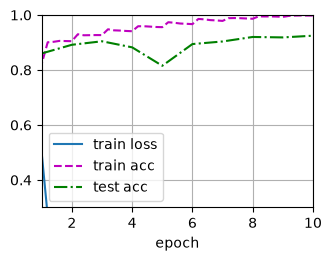

In [12]:
lr = 0.05
num_epochs = 10
batch_size = 128
train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size=batch_size, resize=224)
util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, util.try_gpu(), ylim=(0.3, 1))

In [13]:
torch.save(net.state_dict(), "./models/ResNet.pth")
